# Lasso and Elastic Net: proximal optimization and sparsity

This notebook studies the non-smooth penalized least-squares problem on the real diabetes regression dataset bundled with scikit-learn. It derives the subgradient/KKT conditions, implements proximal gradient descent and compares the resulting regularization path with scikit-learn's coordinate-descent reference.

## 1. Objective and KKT conditions

For centered/scaled predictors, response $y$ and $0\le\rho\le1$, define

$$F(\beta)=\frac{1}{2n}\|y-X\beta\|_2^2+\lambda\left[\rho\|\beta\|_1+\frac{1-\rho}{2}\|\beta\|_2^2\right].$$

$\rho=1$ gives Lasso and $0<\rho<1$ gives Elastic Net. The smooth gradient is $\nabla f=X^T(X\beta-y)/n+\lambda(1-\rho)\beta$. The proximal map for the L1 term is soft-thresholding, $S_a(z)=\operatorname{sign}(z)\max(|z|-a,0)$, so

$$\beta^{k+1}=S_{t\lambda\rho}\left(\beta^k-t\nabla f(\beta^k)\right).$$

At a zero coefficient the KKT condition is $|\nabla_j f|\le\lambda\rho$; otherwise $\nabla_j f+\lambda\rho\operatorname{sign}(\beta_j)=0$. For a convex objective, proximal gradient with $t\le1/L$ has global $O(1/k)$ objective convergence. Coordinate descent is an independent reference for the same convex problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

dataset=load_diabetes(); X_train,X_test,y_train,y_test=train_test_split(dataset.data,dataset.target,test_size=.25,random_state=2026)
scaler=StandardScaler().fit(X_train); X_train=scaler.transform(X_train); X_test=scaler.transform(X_test)
y_mean=y_train.mean(); y_train=y_train-y_mean; y_test=y_test-y_mean; n,p=X_train.shape
def soft_threshold(z,a): return np.sign(z)*np.maximum(np.abs(z)-a,0.0)
def proximal_path(lam,rho,iterations=2500):
    beta=np.zeros(p); L=np.linalg.eigvalsh(X_train.T@X_train/n).max()+lam*(1-rho); t=1/L; history=[]
    for _ in range(iterations):
        grad=X_train.T@(X_train@beta-y_train)/n+lam*(1-rho)*beta
        beta=soft_threshold(beta-t*grad,t*lam*rho)
        residual=y_train-X_train@beta
        history.append(.5*residual@residual/n+lam*(rho*np.abs(beta).sum()+.5*(1-rho)*beta@beta))
    return beta,np.asarray(history)


,rho,model,lambda,nonzero,train_objective,test_rmse
31,0.5,Elastic Net,0.196842,10,1529.707726,54.304048
32,0.5,Elastic Net,0.295521,10,1569.369196,54.264109
33,0.5,Elastic Net,0.443669,10,1623.859751,54.296602
34,0.5,Elastic Net,0.666085,10,1696.374389,54.498744
35,0.5,Elastic Net,1.000000,10,1789.093958,55.005370


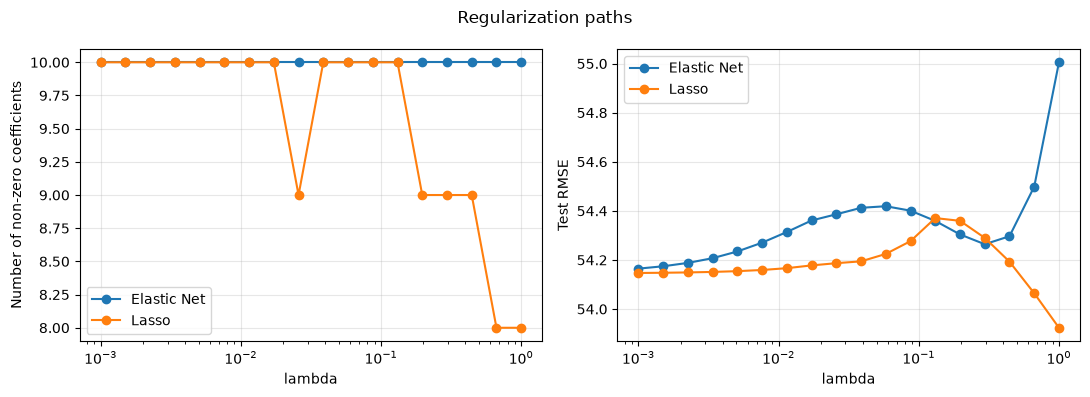

In [2]:
lambdas=np.logspace(-3,0,18); records=[]
for rho,name in [(1.0,'Lasso'),(.5,'Elastic Net')]:
    for lam in lambdas:
        beta,history=proximal_path(lam,rho)
        records.append({'rho':rho,'model':name,'lambda':lam,'nonzero':int(np.count_nonzero(np.abs(beta)>1e-6)),'train_objective':history[-1],'test_rmse':np.sqrt(mean_squared_error(y_test,X_test@beta))})
results=__import__('pandas').DataFrame(records)
fig,axes=plt.subplots(1,2,figsize=(11,4));
for name,group in results.groupby('model'):
    axes[0].semilogx(group['lambda'],group['nonzero'],marker='o',label=name); axes[1].semilogx(group['lambda'],group['test_rmse'],marker='o',label=name)
axes[0].set_ylabel('Number of non-zero coefficients'); axes[1].set_ylabel('Test RMSE');
for ax in axes: ax.set_xlabel('lambda'); ax.legend(); ax.grid(alpha=.3)
fig.suptitle('Regularization paths'); fig.tight_layout(); results.tail()

In [3]:
lam=.05; beta_lasso,_=proximal_path(lam,1.0); beta_enet,_=proximal_path(lam,.5)
lasso_ref=Lasso(alpha=lam,max_iter=10000,tol=1e-10).fit(X_train,y_train)
enet_ref=ElasticNet(alpha=lam,l1_ratio=.5,max_iter=10000,tol=1e-10).fit(X_train,y_train)
print({'Lasso coefficient distance':np.linalg.norm(beta_lasso-lasso_ref.coef_),'Elastic Net coefficient distance':np.linalg.norm(beta_enet-enet_ref.coef_),'Lasso test RMSE':np.sqrt(mean_squared_error(y_test,X_test@beta_lasso)),'Elastic Net test RMSE':np.sqrt(mean_squared_error(y_test,X_test@beta_enet))})

{'Lasso coefficient distance': np.float64(0.2961514714546459), 'Elastic Net coefficient distance': np.float64(3.571770296999323e-08), 'Lasso test RMSE': np.float64(54.21140144963519), 'Elastic Net test RMSE': np.float64(54.4192258892903)}


The L1 kink is why a classical Hessian/Newton step is inappropriate at zero coefficients. The proximal update handles the non-differentiable term exactly, while the smooth quadratic part supplies the gradient and Lipschitz step-size bound.